<img src="https://blog.pearsonlatam.com/hs-fs/hubfs/estrategias-para-evitar-la-deserci%C3%B3n-escolar-en-la-nueva-normalidad%20.jpeg?width=2000&height=852&name=estrategias-para-evitar-la-deserci%C3%B3n-escolar-en-la-nueva-normalidad%20.jpeg" width="6200" height="200"/>

# Fase 2: Datos, modelamiento y validación
**Predicción temprana de deserción estudiantil con SVM bajo diferentes métodos de normalización**

### Mapa de clases
| Clase | Qué hace | Sección |
|---|---|---|
| `Config` | guarda todos los parámetros en un solo lugar | — |
| `GeneradorObjetivo` | crea Graduado / En curso / Desertor si la base no lo trae | 7.1 |
| `DatosDesercion` | carga, revisa calidad, verifica y divide los datos | 7.1 |
| `FabricaPipelines` | arma el preprocesamiento + modelo sin fuga de datos | 7.2 |
| `ExperimentoNormalizacion` | reproduce el artículo (SVM con 9 normalizaciones) | 7.3 |
| `ComparadorModelos` | compara modelos con validación cruzada anidada | 7.3 / 7.4 |
| `EvaluadorFinal` | evalúa el mejor modelo en el conjunto de prueba | 7.4 |
| `Informe` | escribe el informe y la lista de verificación | 7.4 |


In [21]:
import warnings, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler,
                                   QuantileTransformer, PowerTransformer, Normalizer, OneHotEncoder)
from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     StratifiedShuffleSplit, GridSearchCV, cross_validate)
from sklearn.metrics import (make_scorer, f1_score, recall_score, classification_report,
                             ConfusionMatrixDisplay, precision_recall_curve)
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

class Config:
    """Todos los parámetros del proyecto en un solo lugar."""

    def __init__(self, rapido=True):
        self.rapido = rapido
        self.semilla = 42
        self.ruta_datos = "/content/estudiantes_sinteticos_11500.csv"
        self.col_objetivo = "estado_final"
        self.tasa_desercion = 0.25
        self.ruido = 0.6
        self.tamano_prueba = 0.15
        self.n_jobs = -1

        self.n_filas_rapido = 2000
        self.n_ensayos = 3 if rapido else 50
        self.n_pliegues_ext = 3 if rapido else 5
        self.n_repeticiones = 1 if rapido else 2
        self.n_pliegues_int = 2 if rapido else 3
        self.n_permutaciones = 3 if rapido else 15
        self.clases = ["Graduado", "En curso", "Desertor"]
        self.numericas = ["edad_ingreso", "promedio_academico", "materias_reprobadas",
                          "distancia_hogar_ies_km", "puntaje_icfes_percentil", "semestre_cursado",
                          "estrato_socioeconomico"]
        self.educacion = ["nivel_educativo_padre", "nivel_educativo_madre"]
        self.binarias = ["trabaja_mientras_estudia", "beneficiario_icetex", "beneficiario_beca"]
        self.nominales = ["sexo", "estado_civil", "zona_residencia", "departamento", "sector_ies",
                          "nivel_formacion", "metodologia", "area_conocimiento"]
        self.excluir = ["anio_registro"]
        self.carpeta = Path("resultados")
        self.carpeta.mkdir(exist_ok=True)

    @property
    def numericas_modelo(self):
        """Numéricas + educación convertida a número (Ninguno=0 ... Universitario=4)."""
        return self.numericas + [c + "_num" for c in self.educacion]

    @property
    def idx_desertor(self):
        return self.clases.index("Desertor")


def normalizar_texto(valor):
    """Minúsculas y sin tildes, para comparar etiquetas ('Técnico' == 'tecnico')."""
    if pd.isna(valor):
        return np.nan
    texto = unicodedata.normalize("NFKD", str(valor).strip().lower())
    return "".join(c for c in texto if not unicodedata.combining(c))


def crear_scorers(idx_desertor):
    """Métricas usadas en toda la validación (F1 ponderado = principal; Desertor = clase de interés)."""
    return {"f1_weighted": "f1_weighted",
            "f1_macro": "f1_macro",
            "f1_desertor": make_scorer(f1_score, labels=[idx_desertor], average="macro", zero_division=0),
            "recall_desertor": make_scorer(recall_score, labels=[idx_desertor], average="macro", zero_division=0),
            "balanced_accuracy": "balanced_accuracy"}


def a_markdown(tabla, decimales=3):
    """Convierte un DataFrame en tabla Markdown (para el informe)."""
    t = tabla.reset_index()
    filas = ["| " + " | ".join(map(str, t.columns)) + " |", "|" + "---|" * len(t.columns)]
    for _, fila in t.iterrows():
        filas.append("| " + " | ".join(f"{v:.{decimales}f}" if isinstance(v, (float, np.floating)) else str(v)
                                        for v in fila) + " |")
    return "\n".join(filas)


cfg = Config(rapido=True)
print("MODO:", "RÁPIDO (solo prueba)" if cfg.rapido else "COMPLETO", "| scikit-learn", sklearn.__version__)

MODO: RÁPIDO (solo prueba) | scikit-learn 1.6.1


<img src="https://imagenes2.eltiempo.com/files/og_thumbnail/uploads/2020/02/05/5e3b12300470c.jpeg" width="6200" height="200"/>

## 7.1 Consolidación de los datos
Dos clases: `GeneradorObjetivo` (crea la variable objetivo) y `DatosDesercion` (carga, calidad,
verificación y división en desarrollo y prueba).

**Cómo se simuló la variable objetivo:**

1. Se calcula el riesgo de deserción con los factores esperados (ICFES bajo,
promedio bajo, materias reprobadas, trabajar, sin apoyos, ruralidad, modalidad virtual... etc)

2. Se calibra para que la tasa global sea `tasa_desercion`

3. Quien no deserta es Graduado si su semestre
alcanza la duración de su programa, y En curso si no se a graduado todavia.

In [22]:
class GeneradorObjetivo:
    """Crea Graduado / En curso / Desertor cuando la base no trae la variable objetivo."""

    NIVEL_EDUCATIVO = {"ninguno": 0, "primaria": 1, "bachillerato": 2, "tecnico": 3, "universitario": 4}
    DURACION_SEMESTRES = {"tecnico profesional": 4, "tecnologico": 6, "universitario": 10}

    def __init__(self, cfg):
        self.cfg = cfg

    @staticmethod
    def _estandarizar(serie):
        serie = serie.fillna(serie.median())
        return (serie - serie.mean()) / serie.std()

    def _riesgo(self, d, rng):
        z = self._estandarizar
        educacion = d[self.cfg.educacion].apply(lambda c: c.map(lambda v: self.NIVEL_EDUCATIVO.get(normalizar_texto(v), np.nan)))
        virtual = d["metodologia"].map(normalizar_texto).isin(["virtual", "distancia tradicional"]).astype(float)
        rural = (d["zona_residencia"].map(normalizar_texto) == "rural").astype(float)
        riesgo = (-0.55 * z(d["puntaje_icfes_percentil"]) - 0.70 * z(d["promedio_academico"])
                  + 0.35 * z(d["materias_reprobadas"]) + 0.20 * z(np.log1p(d["distancia_hogar_ies_km"]))
                  + 0.30 * d["trabaja_mientras_estudia"].fillna(0) - 0.25 * d["beneficiario_icetex"].fillna(0)
                  - 0.35 * d["beneficiario_beca"].fillna(0) - 0.25 * z(d["estrato_socioeconomico"])
                  - 0.15 * z(educacion.mean(axis=1)) + 0.20 * virtual + 0.15 * rural
                  + 0.10 * z(d["edad_ingreso"]) + self.cfg.ruido * rng.normal(size=len(d)))
        return riesgo.to_numpy()

    def _calibrar_intercepto(self, riesgo):
        """Busca el intercepto para que la tasa media de deserción sea la deseada (bisección)."""
        bajo, alto = -10.0, 10.0
        for _ in range(60):
            medio = (bajo + alto) / 2
            tasa = (1 / (1 + np.exp(-(medio + riesgo)))).mean()
            if tasa > self.cfg.tasa_desercion:
                alto = medio
            else:
                bajo = medio
        return medio

    def generar(self, d):
        rng = np.random.default_rng(self.cfg.semilla)
        riesgo = self._riesgo(d, rng)
        prob_desercion = 1 / (1 + np.exp(-(self._calibrar_intercepto(riesgo) + riesgo)))
        desertor = rng.random(len(d)) < prob_desercion
        duracion = d["nivel_formacion"].map(normalizar_texto).map(self.DURACION_SEMESTRES).fillna(8)
        prob_graduado = 1 / (1 + np.exp(-1.5 * (d["semestre_cursado"].fillna(1) - duracion + 0.5)))
        graduado = (~desertor) & (rng.random(len(d)) < prob_graduado.to_numpy())
        return np.where(desertor, "Desertor", np.where(graduado, "Graduado", "En curso"))


class DatosDesercion:
    """Carga la base, revisa su calidad, agrega/valida el objetivo y la divide en desarrollo y prueba."""

    REGLAS = {"promedio_academico": (0, 5), "puntaje_icfes_percentil": (0, 100), "estrato_socioeconomico": (1, 6),
              "edad_ingreso": (14, 80), "materias_reprobadas": (0, 60), "distancia_hogar_ies_km": (0, 1000),
              "semestre_cursado": (1, 16)}

    def __init__(self, cfg):
        self.cfg = cfg
        self.df = None
        self.n_original = 0
        self.simulado = False
        self.verificacion_ok = None
        self.calidad = None

    def cargar(self):
        cfg = self.cfg
        if not Path(cfg.ruta_datos).exists():
            raise FileNotFoundError(f"No encuentro {cfg.ruta_datos}. Ponga el CSV junto al cuaderno.")
        df = pd.read_csv(cfg.ruta_datos)
        self.n_original = len(df)
        if cfg.rapido:
            df = df.sample(min(cfg.n_filas_rapido, len(df)), random_state=cfg.semilla).reset_index(drop=True)
        for col in cfg.nominales + cfg.educacion:
            df[col] = df[col].astype("string").str.strip()
        self.df = df
        print("Base cargada:", df.shape, "| registros originales:", self.n_original)
        return self

    def revisar_calidad(self):
        """Cuenta nulos y valores fuera de rango. Los fuera de rango pasan a NaN (se imputan luego, sin fuga)."""
        df, filas = self.df, []
        for col, (minimo, maximo) in self.REGLAS.items():
            fuera = (df[col] < minimo) | (df[col] > maximo)
            filas.append({"variable": col, "nulos": int(df[col].isna().sum()), "fuera_de_rango": int(fuera.sum())})
            df.loc[fuera, col] = np.nan
        for col in self.cfg.binarias:
            invalido = df[col].notna() & ~df[col].isin([0, 1])
            filas.append({"variable": col, "nulos": int(df[col].isna().sum()), "fuera_de_rango": int(invalido.sum())})
            df.loc[invalido, col] = np.nan
        self.calidad = pd.DataFrame(filas).set_index("variable")
        self.calidad.to_csv(self.cfg.carpeta / "calidad_datos.csv")
        print("Filas duplicadas exactas:", int(df.duplicated().sum()), "(no hay ID, solo se reportan)")
        return self.calidad

    def preparar_objetivo(self):
        cfg = self.cfg
        if cfg.col_objetivo not in self.df.columns:
            self.simulado = True
            self.df[cfg.col_objetivo] = GeneradorObjetivo(cfg).generar(self.df)
            print("Variable objetivo SIMULADA")
        else:
            equivalencias = {"graduado": "Graduado", "en curso": "En curso", "enrolado": "En curso", "desertor": "Desertor"}
            self.df[cfg.col_objetivo] = self.df[cfg.col_objetivo].map(lambda v: equivalencias.get(normalizar_texto(v), v))
            assert set(self.df[cfg.col_objetivo]) <= set(cfg.clases), "Hay clases inesperadas en el objetivo"
        self.proporciones = self.df[cfg.col_objetivo].value_counts(normalize=True).reindex(cfg.clases)
        print(self.proporciones.round(3).to_string())
        self.df.to_csv(cfg.carpeta / "base_definitiva.csv", index=False)

    def verificar(self):
        """Comprueba que la estructura prevista se cumple (tasa de deserción por grupo) y hace las gráficas."""
        d = self.df.assign(des=(self.df[self.cfg.col_objetivo] == "Desertor").astype(int))
        grupos = {"ICFES (Q1 bajo → Q4 alto)": pd.qcut(d["puntaje_icfes_percentil"], 4, duplicates="drop"),
                  "Promedio (Q1 bajo → Q4 alto)": pd.qcut(d["promedio_academico"], 4, duplicates="drop"),
                  "Trabaja": d["trabaja_mientras_estudia"], "Beca": d["beneficiario_beca"],
                  "Zona": d["zona_residencia"], "Metodología": d["metodologia"]}
        tasas = {nombre: d.groupby(g, observed=True)["des"].mean() for nombre, g in grupos.items()}
        fig, ejes = plt.subplots(2, 3, figsize=(14, 7))
        for eje, (nombre, tasa) in zip(ejes.ravel(), tasas.items()):
            tasa.plot(kind="bar", ax=eje, color="#4c72b0"); eje.set_title(nombre, fontsize=10); eje.set_ylabel("tasa de deserción")
        plt.tight_layout(); plt.savefig(self.cfg.carpeta / "verificacion_datos.png", dpi=130); plt.show()
        if self.simulado:
            icfes, prom = tasas["ICFES (Q1 bajo → Q4 alto)"].to_numpy(), tasas["Promedio (Q1 bajo → Q4 alto)"].to_numpy()
            self.verificacion_ok = bool(icfes[0] > icfes[-1] and prom[0] > prom[-1]
                                        and tasas["Trabaja"].loc[1] > tasas["Trabaja"].loc[0]
                                        and tasas["Beca"].loc[1] < tasas["Beca"].loc[0]
                                        and abs(self.proporciones["Desertor"] - self.cfg.tasa_desercion) < 0.03)
            print("La simulación reproduce la estructura prevista" if self.verificacion_ok else "✘ La simulación NO cumple lo previsto")

    def dividir(self):
        """Devuelve (X_desarrollo, X_prueba, y_desarrollo, y_prueba). La prueba no se toca hasta el final."""
        cfg = self.cfg
        X = self.df.drop(columns=[cfg.col_objetivo] + cfg.excluir, errors="ignore").copy()
        for col in cfg.educacion:
            X[col + "_num"] = X[col].map(lambda v: GeneradorObjetivo.NIVEL_EDUCATIVO.get(normalizar_texto(v), np.nan)).astype(float)
        for col in cfg.nominales:
            X[col] = X[col].astype(object)
        X = X[cfg.numericas_modelo + cfg.binarias + cfg.nominales]
        y = self.df[cfg.col_objetivo].map({c: i for i, c in enumerate(cfg.clases)}).to_numpy()
        X_des, X_test, y_des, y_test = train_test_split(X, y, test_size=cfg.tamano_prueba, stratify=y, random_state=cfg.semilla)
        print("Desarrollo:", X_des.shape, "| Prueba (intocable):", X_test.shape, "| predictores:", X.shape[1])
        return X_des.reset_index(drop=True), X_test.reset_index(drop=True), y_des, y_test

In [23]:
datos = DatosDesercion(cfg).cargar()
datos.revisar_calidad()

Base cargada: (2000, 21) | registros originales: 11500
Filas duplicadas exactas: 0 (no hay ID, solo se reportan)


,nulos,fuera_de_rango
variable,,
promedio_academico,0,0
puntaje_icfes_percentil,0,0
estrato_socioeconomico,0,0
edad_ingreso,0,0
materias_reprobadas,0,0
distancia_hogar_ies_km,0,0
semestre_cursado,0,0
trabaja_mientras_estudia,0,0
beneficiario_icetex,0,0


Variable objetivo SIMULADA
estado_final
Graduado    0.307
En curso    0.435
Desertor    0.258


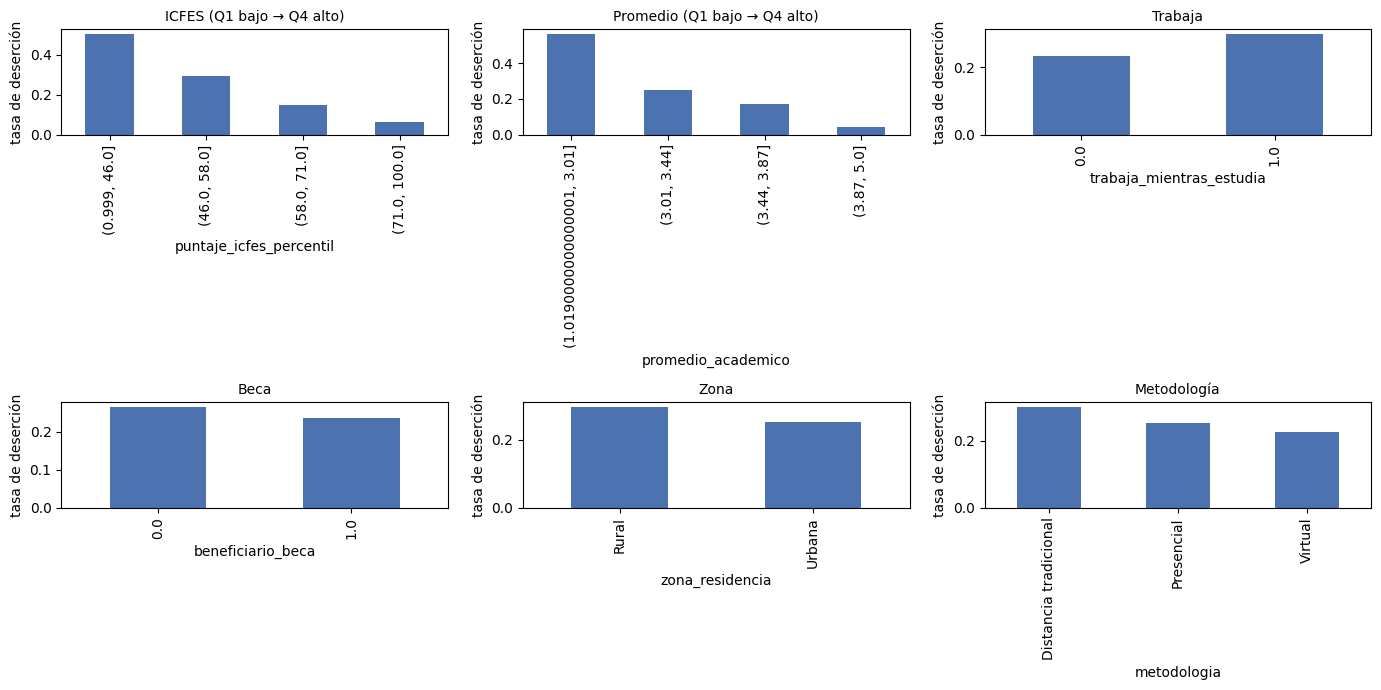

La simulación reproduce la estructura prevista
Desarrollo: (1700, 20) | Prueba (intocable): (300, 20) | predictores: 20


In [24]:
datos.preparar_objetivo()
datos.verificar()
X_des, X_test, y_des, y_test = datos.dividir()

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTB5qfCEPOmbbMhV6ShtpbKTT46TsGM2UeOsCjPA2v-b9i2fv6xqVsn1wI&s=10" width="6200" height="200"/>

## 7.2 Flujo reproducible sin fuga de datos
**Orden de las etapas:** `imputar → codificar → escalar → clasificador`, todo dentro de un Pipeline.

El Pipeline llama fit solo con los datos de entrenamiento de cada partición (medianas,
categorías, medias del escalador). Con los datos de validación/prueba solo aplica transform. Además: el 15 % de prueba se separa antes de ajustar cualquier cosa, el mapa de nivel educativo es fijo, y anio_registrO se excluye para evitar fuga temporal.

FabricaPipelines construye ese flujo y trae un método auditar_fuga que demuestra que no hay fuga.

In [25]:
class FabricaPipelines:
    """Arma el preprocesamiento y los pipelines completos (preprocesamiento + modelo)."""

    def __init__(self, cfg):
        self.cfg = cfg
        self.fuga_ok = None

    def escaladores(self):
        """Los 9 esquemas de normalización que se comparan (None = sin normalización).
        Verifique esta lista contra la tabla del artículo y edítela si difiere."""
        semilla = self.cfg.semilla
        return {"Sin normalización": None, "StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler(),
                "MaxAbsScaler": MaxAbsScaler(), "RobustScaler": RobustScaler(),
                "Quantile (uniforme)": QuantileTransformer(output_distribution="uniform", n_quantiles=200, random_state=semilla),
                "Quantile (normal)": QuantileTransformer(output_distribution="normal", n_quantiles=200, random_state=semilla),
                "PowerTransformer": PowerTransformer(), "Normalizer (L2)": Normalizer()}

    def preprocesador(self, escalador=None):
        c = self.cfg
        pasos_numericos = [("imputar", SimpleImputer(strategy="median"))]
        if escalador is not None:
            pasos_numericos.append(("esc", clone(escalador)))
        categoricas = Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                                ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False))])
        return ColumnTransformer([("num", Pipeline(pasos_numericos), c.numericas_modelo),
                                  ("bin", SimpleImputer(strategy="most_frequent"), c.binarias),
                                  ("nom", categoricas, c.nominales)])

    def pipeline(self, escalador, clasificador):
        return Pipeline([("prep", self.preprocesador(escalador)), ("clf", clasificador)])

    def auditar_fuga(self, X, y):
        """el escalador aprende solo del entrenamiento; compara con un flujo con fuga a propósito."""
        c = self.cfg
        entren, _ = next(StratifiedKFold(5, shuffle=True, random_state=c.semilla).split(X, y))
        prep = self.preprocesador(StandardScaler()).fit(X.iloc[entren], y[entren])
        media_escalador = prep.named_transformers_["num"].named_steps["esc"].mean_
        imputador = SimpleImputer(strategy="median").fit(X.iloc[entren][c.numericas_modelo])
        media_entrenamiento = imputador.transform(X.iloc[entren][c.numericas_modelo]).mean(axis=0)
        assert np.allclose(media_escalador, media_entrenamiento), "¡El escalador vio datos que no debía!"
        print("Las medias del escalador coinciden con las del entrenamiento (no vio validación).")

        cv = StratifiedShuffleSplit(n_splits=max(c.n_ensayos, 5), test_size=0.2, random_state=c.semilla)
        modelo = lambda: SVC(kernel="rbf", max_iter=200_000, random_state=c.semilla)
        X_con_fuga = self.preprocesador(StandardScaler()).fit_transform(X)          # ← FUGA: ajusta con TODO
        con_fuga = cross_validate(modelo(), X_con_fuga, y, cv=cv, scoring="f1_weighted", n_jobs=c.n_jobs)["test_score"].mean()
        sin_fuga = cross_validate(self.pipeline(StandardScaler(), modelo()), X, y, cv=cv, scoring="f1_weighted",
                                  n_jobs=c.n_jobs)["test_score"].mean()
        print(f"F1 con fuga: {con_fuga:.4f} | flujo correcto: {sin_fuga:.4f} | diferencia: {con_fuga - sin_fuga:+.4f}")
        print("(Con un escalador simple la diferencia es pequeña; con SMOTE o selección de variables sería grande.)")
        self.fuga_ok = True

In [26]:
fabrica = FabricaPipelines(cfg)
fabrica.auditar_fuga(X_des, y_des)

Las medias del escalador coinciden con las del entrenamiento (no vio validación).
F1 con fuga: 0.7284 | flujo correcto: 0.7276 | diferencia: +0.0008
(Con un escalador simple la diferencia es pequeña; con SMOTE o selección de variables sería grande.)


<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQf3nV90EwGTEYAGfMEs0p0eo5PrKQSAo8ZuFkoNQaPtX-myC24Eg6FvGZB&s=10" width="6200" height="200"/>

## 7.3 Reproducción y adaptación del método
### 7.3.1 SVM con 9 normalizaciones
`ExperimentoNormalizacion` entrena una SVM con cada esquema de normalización, en varios ensayos aleatorios, y compara con la prueba de Friedman.


In [27]:
class ExperimentoNormalizacion:
    """Prueba un clasificador con cada método de normalización y compara los resultados."""

    def __init__(self, cfg, fabrica, titulo, crear_clasificador):
        self.cfg, self.fabrica, self.titulo = cfg, fabrica, titulo
        self.crear_clasificador = crear_clasificador
        self.tabla = None
        self.f1_por_ensayo = {}
        self.friedman = None

    def correr(self, X, y):
        cfg = self.cfg
        particiones = StratifiedShuffleSplit(n_splits=cfg.n_ensayos, test_size=0.2, random_state=cfg.semilla)
        scorers, filas = crear_scorers(cfg.idx_desertor), []
        print(self.titulo)
        for nombre, escalador in self.fabrica.escaladores().items():
            pipe = self.fabrica.pipeline(escalador, self.crear_clasificador())
            r = cross_validate(pipe, X, y, cv=particiones, scoring=scorers, n_jobs=cfg.n_jobs, error_score=np.nan)
            self.f1_por_ensayo[nombre] = r["test_f1_weighted"]
            filas.append({"normalización": nombre, "f1_ponderado": np.nanmean(r["test_f1_weighted"]),
                          "sd": np.nanstd(r["test_f1_weighted"]), "f1_desertor": np.nanmean(r["test_f1_desertor"]),
                          "recall_desertor": np.nanmean(r["test_recall_desertor"])})
            print(f"  {nombre:<22s} F1 ponderado = {filas[-1]['f1_ponderado']:.3f} ± {filas[-1]['sd']:.3f}")
        self.tabla = pd.DataFrame(filas).set_index("normalización")
        if cfg.n_ensayos >= 3:
            chi, p = stats.friedmanchisquare(*[np.nan_to_num(v) for v in self.f1_por_ensayo.values()])
            self.friedman = p
            print(f"  Prueba de Friedman: p = {p:.4g}")
        self.tabla.to_csv(cfg.carpeta / f"normalizacion_{self.titulo[0]}.csv")
        return self

    def graficar(self, eje):
        eje.boxplot(list(self.f1_por_ensayo.values())); eje.set_xticklabels(list(self.f1_por_ensayo.keys()), rotation=45, fontsize=8)
        eje.set_title(self.titulo, fontsize=9); eje.set_ylabel("F1 ponderado")

A) SVM polinómica grado 3 (fiel al artículo)
  Sin normalización      F1 ponderado = 0.647 ± 0.024
  StandardScaler         F1 ponderado = 0.706 ± 0.024
  MinMaxScaler           F1 ponderado = 0.677 ± 0.011
  MaxAbsScaler           F1 ponderado = 0.681 ± 0.012
  RobustScaler           F1 ponderado = 0.712 ± 0.030
  Quantile (uniforme)    F1 ponderado = 0.689 ± 0.021
  Quantile (normal)      F1 ponderado = 0.601 ± 0.020
  PowerTransformer       F1 ponderado = 0.709 ± 0.023
  Normalizer (L2)        F1 ponderado = 0.543 ± 0.023
  Prueba de Friedman: p = 0.005169
B) SVM polinómica grado 3 + class_weight
  Sin normalización      F1 ponderado = 0.598 ± 0.011
  StandardScaler         F1 ponderado = 0.695 ± 0.010
  MinMaxScaler           F1 ponderado = 0.670 ± 0.009
  MaxAbsScaler           F1 ponderado = 0.667 ± 0.005
  RobustScaler           F1 ponderado = 0.693 ± 0.012
  Quantile (uniforme)    F1 ponderado = 0.671 ± 0.010
  Quantile (normal)      F1 ponderado = 0.592 ± 0.025
  PowerTransfor

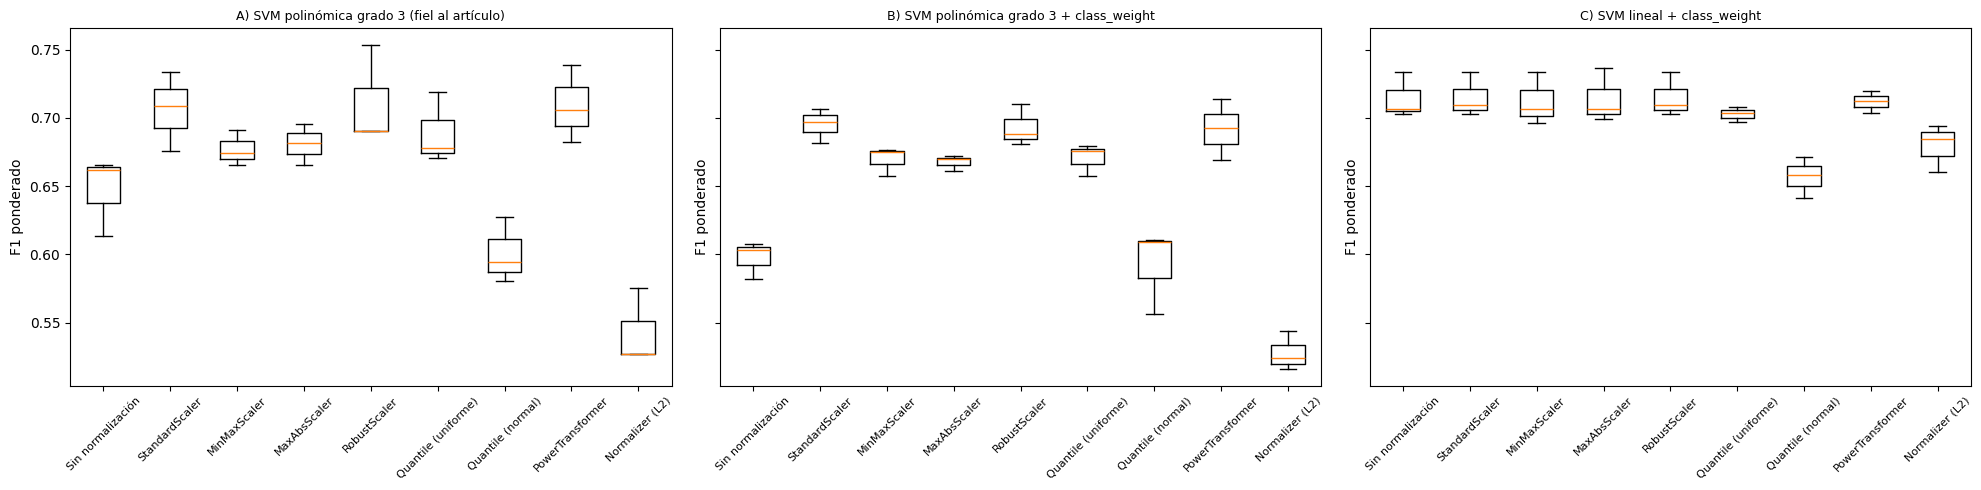

In [28]:
exp_A = ExperimentoNormalizacion(cfg, fabrica, "A) SVM polinómica grado 3 (fiel al artículo)",
                                 lambda: SVC(kernel="poly", degree=3, max_iter=200_000, random_state=cfg.semilla)).correr(X_des, y_des)
exp_B = ExperimentoNormalizacion(cfg, fabrica, "B) SVM polinómica grado 3 + class_weight",
                                 lambda: SVC(kernel="poly", degree=3, class_weight="balanced", max_iter=200_000, random_state=cfg.semilla)).correr(X_des, y_des)
exp_C = ExperimentoNormalizacion(cfg, fabrica, "C) SVM lineal + class_weight",
                                 lambda: LinearSVC(class_weight="balanced", dual=False, max_iter=5000, random_state=cfg.semilla)).correr(X_des, y_des)

fig, ejes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
for eje, exp in zip(ejes, [exp_A, exp_B, exp_C]):
    exp.graficar(eje)
plt.tight_layout(); plt.savefig(cfg.carpeta / "normalizaciones.png", dpi=130); plt.show()

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRFxrd0vuBrAuwhzi3qcJSHD4xmCTfGVZMs_xV7nFhSbF60wzE2jz4BIrRh&s=10" width="6200" height="200"/>

### 7.3.2 Modelos avanzados frente a la línea base


In [29]:
class ComparadorModelos:
    """Compara todos los modelos con validación cruzada anidada y los contrasta con la línea base."""

    def __init__(self, cfg, fabrica):
        self.cfg, self.fabrica = cfg, fabrica
        self.scorers = crear_scorers(cfg.idx_desertor)
        self.modelos = self._definir_modelos()
        self.resultados, self.params_elegidos = {}, {}

    def _reducir(self, grilla):
        """En modo rápido solo se prueba una combinación (para verificar que el flujo corre)."""
        return {k: v[:1] for k, v in grilla.items()} if self.cfg.rapido else grilla

    def _definir_modelos(self):
        f, s = self.fabrica, self.cfg.semilla
        escaladores = [StandardScaler(), MinMaxScaler(), PowerTransformer()]
        M = {}
        M["Baseline_Mayoria"] = (f.pipeline(None, DummyClassifier(strategy="most_frequent")), {})
        M["Baseline_LogReg"] = (f.pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), {})
        M["LogReg ajustada"] = (f.pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")),
                                self._reducir({"clf__C": [0.01, 0.1, 1, 10]}))
        M["SVM lineal"] = (f.pipeline(StandardScaler(), LinearSVC(dual=False, class_weight="balanced", max_iter=5000, random_state=s)),
                           self._reducir({"clf__C": [0.01, 0.1, 1, 10], "prep__num__esc": escaladores}))
        M["SVM polinómica"] = (f.pipeline(StandardScaler(), SVC(kernel="poly", class_weight="balanced", max_iter=200_000, random_state=s)),
                               self._reducir({"clf__C": [0.1, 1, 10], "clf__degree": [2, 3], "clf__coef0": [0, 1],
                                              "prep__num__esc": escaladores}))
        M["SVM RBF"] = (f.pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced", max_iter=200_000, random_state=s)),
                        self._reducir({"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", 0.01, 0.1], "prep__num__esc": escaladores}))
        M["Random Forest"] = (f.pipeline(None, RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=s)),
                              self._reducir({"clf__max_depth": [None, 8, 16], "clf__min_samples_leaf": [1, 5]}))
        M["Gradient Boosting"] = (f.pipeline(None, HistGradientBoostingClassifier(class_weight="balanced", random_state=s)),
                                  self._reducir({"clf__learning_rate": [0.05, 0.1], "clf__max_leaf_nodes": [15, 31]}))
        if HAY_XGBOOST:
            M["XGBoost"] = (f.pipeline(None, XGBClassifier(n_estimators=300, eval_metric="mlogloss", random_state=s, n_jobs=1)),
                            self._reducir({"clf__max_depth": [3, 6], "clf__learning_rate": [0.05, 0.1]}))
        return M

    def correr(self, X, y):
        cfg = self.cfg
        externa = RepeatedStratifiedKFold(n_splits=cfg.n_pliegues_ext, n_repeats=cfg.n_repeticiones, random_state=cfg.semilla)
        interna = StratifiedKFold(cfg.n_pliegues_int, shuffle=True, random_state=cfg.semilla)
        for nombre, (pipe, grilla) in self.modelos.items():
            modelo = GridSearchCV(pipe, grilla, cv=interna, scoring="f1_weighted") if grilla else pipe
            r = cross_validate(modelo, X, y, cv=externa, scoring=self.scorers, return_estimator=True, n_jobs=cfg.n_jobs)
            self.resultados[nombre] = pd.DataFrame({m: r[f"test_{m}"] for m in self.scorers})
            self.params_elegidos[nombre] = [str(getattr(e, "best_params_", {})) for e in r["estimator"]]
            res = self.resultados[nombre]
            print(f"{nombre:<20s} F1 ponderado = {res.f1_weighted.mean():.3f} ± {res.f1_weighted.std():.3f} | "
                  f"F1 Desertor = {res.f1_desertor.mean():.3f} ± {res.f1_desertor.std():.3f}")
        return self

    def resumen(self):
        medias = pd.DataFrame({n: r.mean() for n, r in self.resultados.items()}).T
        desvios = pd.DataFrame({n: r.std() for n, r in self.resultados.items()}).T
        return medias.sort_values("f1_weighted", ascending=False), desvios

    def tabla_media_sd(self):
        medias, desvios = self.resumen()
        return medias.map("{:.3f}".format) + " ± " + desvios.loc[medias.index].map("{:.3f}".format)

    def pruebas_contra_baseline(self):
        """Prueba de Wilcoxon pareada (mismos pliegues) contra la regresión logística básica.
        Se aplica corrección de Bonferroni por comparar varios modelos."""
        base = self.resultados["Baseline_LogReg"]
        candidatos = [n for n in self.resultados if not n.startswith("Baseline")]
        filas = []
        for metrica in ["f1_weighted", "f1_desertor"]:
            for nombre in candidatos:
                diferencia = self.resultados[nombre][metrica].to_numpy() - base[metrica].to_numpy()
                try:
                    p = stats.wilcoxon(diferencia).pvalue
                except ValueError:
                    p = 1.0
                filas.append({"metrica": metrica, "modelo": nombre, "mejora_media": diferencia.mean(),
                              "p_bruto": p, "p_bonferroni": min(1.0, p * len(candidatos))})
        tabla = pd.DataFrame(filas)
        tabla.to_csv(self.cfg.carpeta / "pruebas_vs_baseline.csv", index=False)
        return tabla

    def mejor_modelo(self):
        medias, _ = self.resumen()
        return medias.drop([n for n in medias.index if n.startswith("Baseline")])["f1_weighted"].idxmax()

In [30]:
try:
    from xgboost import XGBClassifier
    HAY_XGBOOST = True
except ImportError:
    HAY_XGBOOST = False

comparador = ComparadorModelos(cfg, fabrica).correr(X_des, y_des)

Baseline_Mayoria     F1 ponderado = 0.263 ± 0.001 | F1 Desertor = 0.000 ± 0.000
Baseline_LogReg      F1 ponderado = 0.703 ± 0.016 | F1 Desertor = 0.496 ± 0.009
LogReg ajustada      F1 ponderado = 0.706 ± 0.001 | F1 Desertor = 0.564 ± 0.019
SVM lineal           F1 ponderado = 0.712 ± 0.014 | F1 Desertor = 0.518 ± 0.028
SVM polinómica       F1 ponderado = 0.703 ± 0.004 | F1 Desertor = 0.580 ± 0.032
SVM RBF              F1 ponderado = 0.686 ± 0.005 | F1 Desertor = 0.582 ± 0.029
Random Forest        F1 ponderado = 0.717 ± 0.018 | F1 Desertor = 0.509 ± 0.025
Gradient Boosting    F1 ponderado = 0.717 ± 0.012 | F1 Desertor = 0.530 ± 0.025
XGBoost              F1 ponderado = 0.713 ± 0.012 | F1 Desertor = 0.495 ± 0.019


In [31]:
tabla_resultados = comparador.tabla_media_sd().loc[comparador.resumen()[0].index]
tabla_resultados.to_csv(cfg.carpeta / "resultados_validacion_anidada.csv")
tabla_resultados

,f1_weighted,f1_macro,f1_desertor,recall_desertor,balanced_accuracy
Random Forest,0.717 ± 0.018,0.694 ± 0.019,0.509 ± 0.025,0.451 ± 0.028,0.694 ± 0.019
Gradient Boosting,0.717 ± 0.012,0.696 ± 0.014,0.530 ± 0.025,0.524 ± 0.036,0.697 ± 0.014
XGBoost,0.713 ± 0.012,0.689 ± 0.013,0.495 ± 0.019,0.446 ± 0.027,0.690 ± 0.013
SVM lineal,0.712 ± 0.014,0.691 ± 0.016,0.518 ± 0.028,0.508 ± 0.037,0.693 ± 0.016
LogReg ajustada,0.706 ± 0.001,0.691 ± 0.003,0.564 ± 0.019,0.606 ± 0.044,0.696 ± 0.003
SVM polinómica,0.703 ± 0.004,0.690 ± 0.005,0.580 ± 0.032,0.594 ± 0.063,0.695 ± 0.006
Baseline_LogReg,0.703 ± 0.016,0.680 ± 0.017,0.496 ± 0.009,0.472 ± 0.015,0.680 ± 0.018
SVM RBF,0.686 ± 0.005,0.676 ± 0.009,0.582 ± 0.029,0.660 ± 0.053,0.685 ± 0.010
Baseline_Mayoria,0.263 ± 0.001,0.202 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.333 ± 0.000


In [32]:
pruebas = comparador.pruebas_contra_baseline()
print("Mejora positiva = supera a la regresión logística básica. Con pocos pliegues Wilcoxon tiene poca potencia.")
pruebas.round(4)

Mejora positiva = supera a la regresión logística básica. Con pocos pliegues Wilcoxon tiene poca potencia.


,metrica,modelo,mejora_media,p_bruto,p_bonferroni
0,f1_weighted,LogReg ajustada,0.0029,1.00,1.0
1,f1_weighted,SVM lineal,0.0090,0.50,1.0
2,f1_weighted,SVM polinómica,0.0001,1.00,1.0
3,f1_weighted,SVM RBF,-0.0169,0.25,1.0
4,f1_weighted,Random Forest,0.0140,0.25,1.0
5,f1_weighted,Gradient Boosting,0.0135,0.25,1.0
6,f1_weighted,XGBoost,0.0102,0.25,1.0
7,f1_desertor,LogReg ajustada,0.0682,0.25,1.0
8,f1_desertor,SVM lineal,0.0218,0.50,1.0
9,f1_desertor,SVM polinómica,0.0835,0.25,1.0


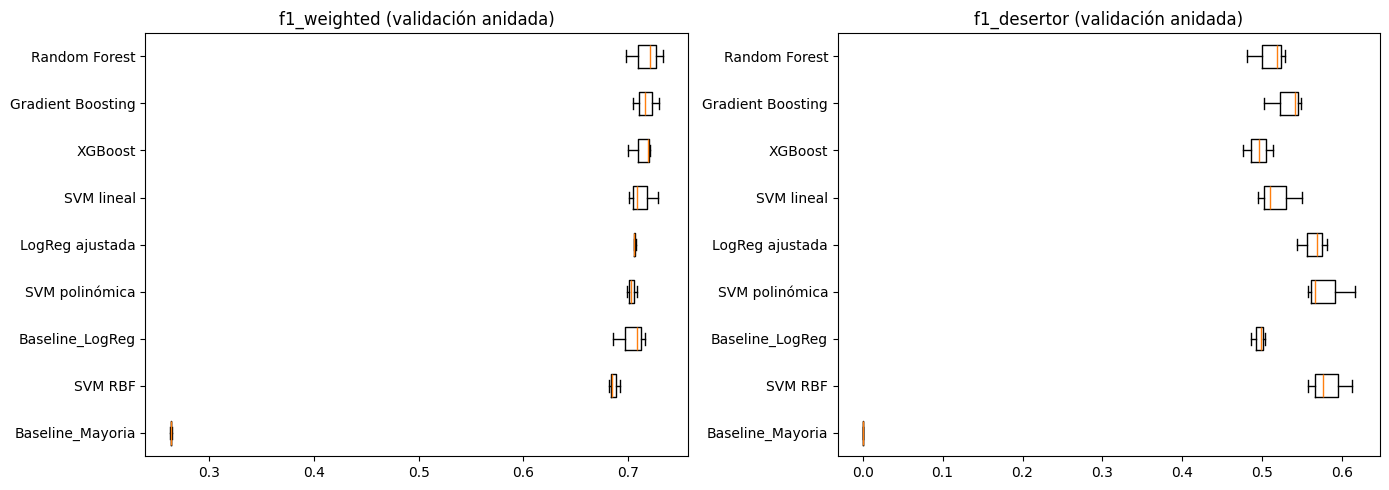

In [33]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
orden = comparador.resumen()[0]["f1_weighted"].sort_values().index
for eje, metrica in zip(ejes, ["f1_weighted", "f1_desertor"]):
    eje.boxplot([comparador.resultados[n][metrica] for n in orden], vert=False)
    eje.set_yticklabels(list(orden)); eje.set_title(f"{metrica} (validación anidada)")
plt.tight_layout(); plt.savefig(cfg.carpeta / "modelos.png", dpi=130); plt.show()

<img src="https://worldvisionamericalatina.org/wp-content/uploads/2023/07/Causas-de-la-desercion-escolar-banner.jpg" width="6200" height="200"/>

## 7.4 Evaluación final e interpretación
`EvaluadorFinal` re-ajusta el mejor modelo con todo el conjunto de desarrollo y lo evalúa una sola vez en el 15 % de prueba. Luego muestra la matriz de confusión, la curva precisión–recall para Desertor, las variables más importantes, y quiénes son los desertores que se escapan.

In [34]:
class EvaluadorFinal:
    """Evalúa el mejor modelo en el conjunto de prueba y lo interpreta."""

    def __init__(self, cfg, comparador, X_des, y_des, X_test, y_test):
        self.cfg, self.comparador = cfg, comparador
        self.X_des, self.y_des, self.X_test, self.y_test = X_des, y_des, X_test, y_test
        self.nombre = comparador.mejor_modelo()
        self.scorers = crear_scorers(cfg.idx_desertor)

    def ajustar(self):
        cfg = self.cfg
        pipe, grilla = self.comparador.modelos[self.nombre]
        interna = StratifiedKFold(cfg.n_pliegues_int + 1, shuffle=True, random_state=cfg.semilla)
        self.modelo = GridSearchCV(clone(pipe), grilla, cv=interna, scoring="f1_weighted") if grilla else clone(pipe)
        self.modelo.fit(self.X_des, self.y_des)
        self.pred = self.modelo.predict(self.X_test)
        print("Mejor modelo:", self.nombre, "|", getattr(self.modelo, "best_params_", ""))
        return self

    def metricas(self):
        cfg, yt, yp = self.cfg, self.y_test, self.pred
        self.resultado = {"f1_ponderado": f1_score(yt, yp, average="weighted"),
                          "f1_macro": f1_score(yt, yp, average="macro"),
                          "f1_desertor": f1_score(yt, yp, labels=[cfg.idx_desertor], average="macro"),
                          "recall_desertor": recall_score(yt, yp, labels=[cfg.idx_desertor], average="macro")}
        print(classification_report(yt, yp, target_names=cfg.clases, digits=3, zero_division=0))
        fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
        ConfusionMatrixDisplay.from_predictions(yt, yp, display_labels=cfg.clases, ax=ejes[0], cmap="Blues", colorbar=False)
        ConfusionMatrixDisplay.from_predictions(yt, yp, display_labels=cfg.clases, ax=ejes[1], cmap="Blues",
                                                normalize="true", colorbar=False, values_format=".2f")
        ejes[0].set_title("Conteos"); ejes[1].set_title("Proporción por clase real (recall)")
        plt.tight_layout(); plt.savefig(cfg.carpeta / "confusion.png", dpi=130); plt.show()
        pd.Series(self.resultado).to_csv(cfg.carpeta / "metricas_prueba.csv")

    def _puntaje_desertor(self):
        """Puntaje continuo de 'Desertor' (probabilidad o distancia al hiperplano)."""
        col = list(self.modelo.classes_).index(self.cfg.idx_desertor)
        if hasattr(self.modelo, "predict_proba"):
            return self.modelo.predict_proba(self.X_test)[:, col]
        if hasattr(self.modelo, "decision_function"):
            return self.modelo.decision_function(self.X_test)[:, col]
        return None

    def curva_umbral(self):
        puntaje = self._puntaje_desertor()
        self.tabla_umbral = pd.DataFrame()
        if puntaje is None:
            return
        precision, recall, umbrales = precision_recall_curve(self.y_test == self.cfg.idx_desertor, puntaje)
        plt.figure(figsize=(5.5, 4.5)); plt.plot(recall, precision)
        plt.axhline((self.y_test == self.cfg.idx_desertor).mean(), ls="--", c="gray", label="azar")
        plt.xlabel("Recall Desertor"); plt.ylabel("Precisión Desertor"); plt.legend(); plt.title("Curva precisión–recall")
        plt.savefig(self.cfg.carpeta / "curva_pr.png", dpi=130); plt.show()
        filas = []
        for objetivo in [0.6, 0.7, 0.8, 0.9]:
            i = np.where(recall[:-1] >= objetivo)[0]
            if len(i):
                i = i[-1]
                filas.append({"recall_objetivo": objetivo, "precision": precision[i],
                              "estudiantes_alertados": (puntaje >= umbrales[i]).mean()})
        self.tabla_umbral = pd.DataFrame(filas)
        print(self.tabla_umbral.round(3).to_string(index=False))

    def importancia(self):
        r = permutation_importance(self.modelo, self.X_test, self.y_test, scoring=self.scorers["f1_desertor"],
                                   n_repeats=self.cfg.n_permutaciones, random_state=self.cfg.semilla, n_jobs=self.cfg.n_jobs)
        self.imp = pd.DataFrame({"variable": self.X_test.columns, "importancia": r.importances_mean,
                                 "sd": r.importances_std}).sort_values("importancia", ascending=False)
        self.imp.to_csv(self.cfg.carpeta / "importancia.csv", index=False)
        top = self.imp.head(12).iloc[::-1]
        plt.figure(figsize=(7, 5)); plt.barh(top["variable"], top["importancia"], xerr=top["sd"], color="#4c72b0")
        plt.xlabel("Caída del F1 de Desertor al mezclar la variable"); plt.tight_layout()
        plt.savefig(self.cfg.carpeta / "importancia.png", dpi=130); plt.show()

    def errores(self):
        """Compara los desertores detectados con los que se escaparon y mira el recall por subgrupo."""
        idx = self.cfg.idx_desertor
        E = self.X_test.copy(); E["real"], E["pred"] = self.y_test, self.pred
        self.perdidos = E[(E.real == idx) & (E.pred != idx)]
        self.detectados = E[(E.real == idx) & (E.pred == idx)]
        cols = self.cfg.numericas_modelo + self.cfg.binarias
        print(f"Desertores reales: {(E.real == idx).sum()} | detectados: {len(self.detectados)} | perdidos: {len(self.perdidos)}")
        print(pd.DataFrame({"detectados": self.detectados[cols].mean(), "perdidos": self.perdidos[cols].mean()}).round(2))
        filas = []
        for col in ["sexo", "zona_residencia", "sector_ies", "metodologia"]:
            for grupo, sub in E[E.real == idx].groupby(col):
                if len(sub) >= 10:
                    filas.append({"variable": col, "grupo": grupo, "n_desertores": len(sub), "recall": (sub.pred == idx).mean()})
        self.por_grupo = pd.DataFrame(filas)
        self.por_grupo.to_csv(self.cfg.carpeta / "recall_por_subgrupo.csv", index=False)
        print("\nRecall de Desertor por subgrupo:"); print(self.por_grupo.round(3).to_string(index=False))

Mejor modelo: Random Forest | {'clf__max_depth': None, 'clf__min_samples_leaf': 1}
              precision    recall  f1-score   support

    Graduado      0.747     0.772     0.759        92
    En curso      0.757     0.855     0.803       131
    Desertor      0.596     0.442     0.507        77

    accuracy                          0.723       300
   macro avg      0.700     0.689     0.690       300
weighted avg      0.713     0.723     0.714       300



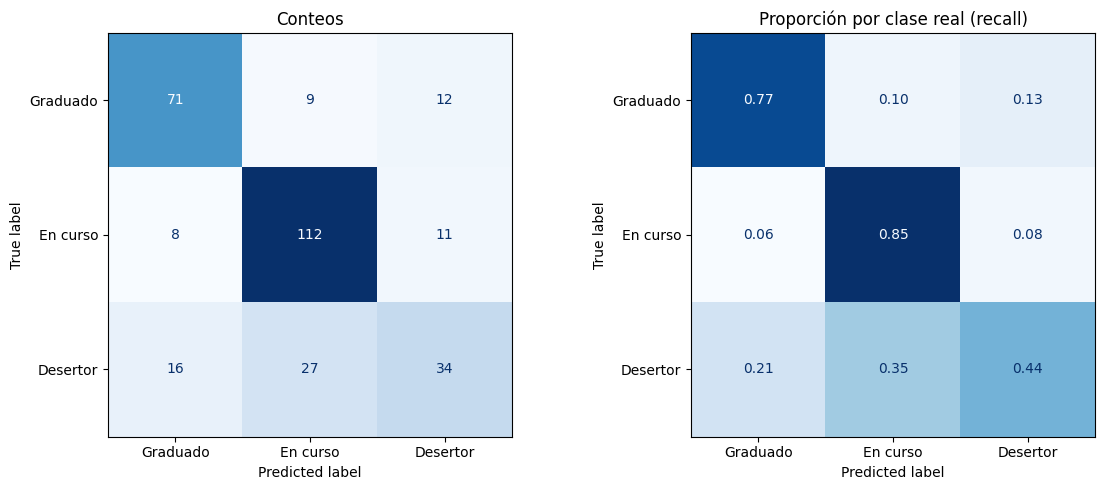

In [35]:
final = EvaluadorFinal(cfg, comparador, X_des, y_des, X_test, y_test).ajustar()
final.metricas()

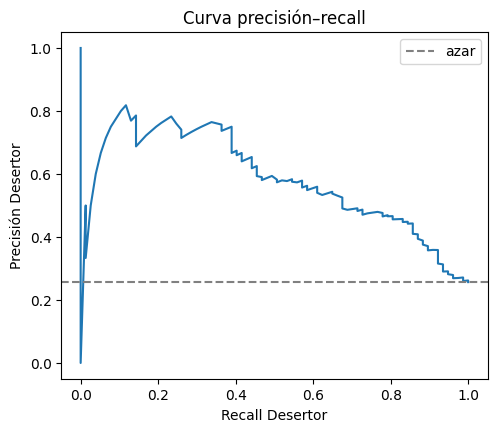

 recall_objetivo  precision  estudiantes_alertados
             0.6      0.560                  0.280
             0.7      0.491                  0.373
             0.8      0.466                  0.443
             0.9      0.359                  0.650


In [36]:
final.curva_umbral()

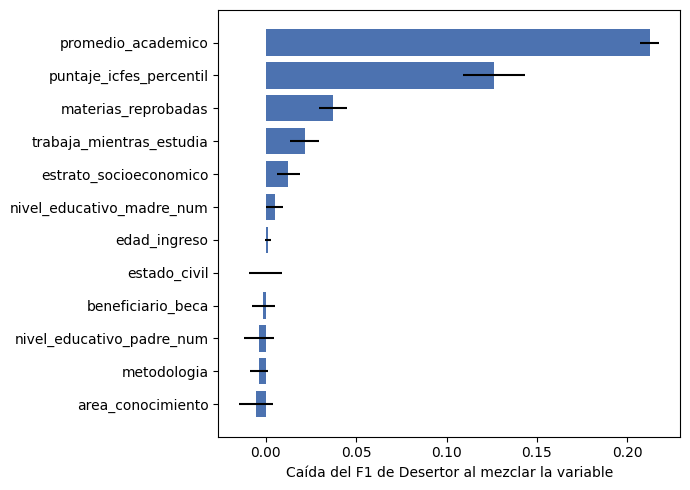

,variable,importancia,sd
1,promedio_academico,0.2123,0.0052
4,puntaje_icfes_percentil,0.1262,0.0171
2,materias_reprobadas,0.0372,0.0079
9,trabaja_mientras_estudia,0.0215,0.0079
6,estrato_socioeconomico,0.0125,0.0064
8,nivel_educativo_madre_num,0.0049,0.0048
0,edad_ingreso,0.0011,0.0018
13,estado_civil,0.0001,0.0091
11,beneficiario_beca,-0.0013,0.0064
7,nivel_educativo_padre_num,-0.0037,0.0081


In [37]:
final.importancia()
final.imp.head(10).round(4)

In [38]:
final.errores()

Desertores reales: 77 | detectados: 34 | perdidos: 43
                           detectados  perdidos
edad_ingreso                    19.68     20.47
promedio_academico               2.47      3.34
materias_reprobadas              2.29      1.02
distancia_hogar_ies_km          15.77     10.49
puntaje_icfes_percentil         38.18     51.37
semestre_cursado                 6.59      6.23
estrato_socioeconomico           2.41      2.28
nivel_educativo_padre_num        2.12      2.00
nivel_educativo_madre_num        1.76      2.14
trabaja_mientras_estudia         0.53      0.40
beneficiario_icetex              0.24      0.12
beneficiario_beca                0.15      0.16

Recall de Desertor por subgrupo:
       variable                 grupo  n_desertores  recall
           sexo                Hombre            33   0.455
           sexo                 Mujer            44   0.432
zona_residencia                 Rural            18   0.500
zona_residencia                Urbana           

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ1TBOPic8h4b_whpZ_F_YzLbILpqpgKDVj5bXeDmTy5Z4vueC6QMlPRv8&s=10" width="6200" height="200"/>

## Informe y lista de verificación
`Informe` escribe un resumen con los resultados reales de esta corrida (texto + tablas) y revisa,
punto por punto, que se cumplan los criterios de la rúbrica.

In [39]:
class Informe:
    """Escribe la lectura de resultados, el informe en Markdown y la lista de verificación."""

    def __init__(self, cfg, datos, fabrica, experimentos, comparador, pruebas, final):
        self.cfg, self.datos, self.fabrica = cfg, datos, fabrica
        self.experimentos, self.comparador, self.pruebas, self.final = experimentos, comparador, pruebas, final

    def lectura(self):
        A, B = self.experimentos[0], self.experimentos[1]
        mejor, tabla = self.final.nombre, B.tabla["f1_ponderado"]
        res = self.comparador.resultados[mejor]
        p = self.pruebas[(self.pruebas.modelo == mejor) & (self.pruebas.metrica == "f1_weighted")].iloc[0]
        supera = p.mejora_media > 0 and p.p_bonferroni < 0.05
        r = self.final.resultado
        top = ", ".join(self.final.imp.head(5).variable)
        frases = [
            f"Normalización: con la SVM polinómica, la mejor fue {tabla.idxmax()} (F1 ponderado {tabla.max():.3f}) y la peor {tabla.idxmin()} "
            f"({tabla.min():.3f}); sin normalizar dio {tabla['Sin normalización']:.3f}."
            + (f" Friedman p = {B.friedman:.3g}." if B.friedman is not None else ""),
            f"Mejor modelo: {mejor}, con F1 ponderado {res.f1_weighted.mean():.3f} ± {res.f1_weighted.std():.3f} en validación anidada "
            f"y {r['f1_ponderado']:.3f} en el conjunto de prueba (F1 Desertor {r['f1_desertor']:.3f}, recall Desertor {r['recall_desertor']:.3f}).",
            f"Frente a la regresión logística básica, la diferencia media en F1 ponderado es {p.mejora_media:+.3f} "
            f"({'estadísticamente significativa' if supera else 'NO estadísticamente significativa'}; p con Bonferroni = {p.p_bonferroni:.3g}).",
            f"Variables más importantes: {top}.",
            f"Errores: se perdieron {len(self.final.perdidos)} desertores del conjunto de prueba; hay que revisar su perfil y las brechas por subgrupo.",
            "Limitaciones: " + ("la etiqueta es simulada (los resultados prueban la metodología, no la predicción real); " if self.datos.simulado else "")
            + ("esta corrida es RÁPIDA y no es reportable; " if self.cfg.rapido else "")
            + "verifique la lista de 9 normalizaciones contra el artículo; la base tiene menos predictores que los 36 previstos."]
        for f in frases:
            print("•", f, "\n")
        return frases

    def guardar(self, frases):
        c, d = self.cfg, self.datos
        texto = f"""# Resultados de la Fase 2
*Modo: {'RÁPIDO (prueba)' if c.rapido else 'completo'} · semilla {c.semilla}*

## Datos
Registros: {d.n_original}. Objetivo {'simulado' if d.simulado else 'observado'}. Proporciones: {', '.join(f'{k} {v:.1%}' for k, v in d.proporciones.items())}.

{a_markdown(d.calidad)}

## Reproducción del artículo
**A) SVM polinómica fiel**

{a_markdown(self.experimentos[0].tabla)}

**B) SVM polinómica con class_weight**

{a_markdown(self.experimentos[1].tabla)}

## Comparación de modelos (validación anidada, media ± sd)
{a_markdown(self.comparador.tabla_media_sd().loc[self.comparador.resumen()[0].index])}

## Pruebas contra la línea base
{a_markdown(self.pruebas)}

## Lectura
""" + "\n".join(f"- {f}" for f in frases)
        (c.carpeta / "informe_resultados.md").write_text(texto, encoding="utf-8")
        print("Informe guardado en", c.carpeta / "informe_resultados.md")

    def lista_verificacion(self):
        c, d = self.cfg, self.datos
        puntos = [("1 Datos", "Al menos 5 000 registros", d.n_original >= 5000),
                  ("1 Datos", "Calidad revisada y fuera de rango tratado", d.calidad is not None),
                  ("1 Datos", "Simulación verificada (o etiqueta real)", d.verificacion_ok is not False),
                  ("2 Fuga", "Preprocesamiento dentro del Pipeline y auditado", bool(self.fabrica.fuga_ok)),
                  ("2 Fuga", "Conjunto de prueba separado antes de ajustar", len(self.final.X_test) > 0),
                  ("3 Método", "9 normalizaciones evaluadas", len(self.fabrica.escaladores()) == 9),
                  ("3 Método", "50 ensayos como el artículo (modo completo)", c.n_ensayos >= 50),
                  ("3 Método", "SVM lineal/polinómica, ensambles y línea base", all(k in self.comparador.resultados for k in ["SVM lineal", "SVM polinómica", "Random Forest", "Baseline_LogReg"])),
                  ("3 Método", "XGBoost incluido", "XGBoost" in self.comparador.resultados),
                  ("4 Validación", "Validación anidada con 10 pliegues externos", c.n_pliegues_ext * c.n_repeticiones >= 10),
                  ("4 Validación", "Pruebas estadísticas contra la línea base", len(self.pruebas) > 0),
                  ("4 Validación", "Importancia, errores y subgrupos", len(self.final.imp) > 0),
                  ("5 Comunicación", "Informe generado", (c.carpeta / "informe_resultados.md").exists())]
        tabla = pd.DataFrame(puntos, columns=["criterio", "verificación", "ok"])
        tabla["estado"] = tabla["ok"].map({True: "✔", False: "✘"})
        print(tabla[["criterio", "verificación", "estado"]].to_string(index=False))

In [40]:
informe = Informe(cfg, datos, fabrica, [exp_A, exp_B, exp_C], comparador, pruebas, final)
frases = informe.lectura()
informe.guardar(frases)
informe.lista_verificacion()

• Normalización: con la SVM polinómica, la mejor fue StandardScaler (F1 ponderado 0.695) y la peor Normalizer (L2) (0.528); sin normalizar dio 0.598. Friedman p = 0.00553. 

• Mejor modelo: Random Forest, con F1 ponderado 0.717 ± 0.018 en validación anidada y 0.714 en el conjunto de prueba (F1 Desertor 0.507, recall Desertor 0.442). 

• Frente a la regresión logística básica, la diferencia media en F1 ponderado es +0.014 (NO estadísticamente significativa; p con Bonferroni = 1). 

• Variables más importantes: promedio_academico, puntaje_icfes_percentil, materias_reprobadas, trabaja_mientras_estudia, estrato_socioeconomico. 

• Errores: se perdieron 43 desertores del conjunto de prueba; hay que revisar su perfil y las brechas por subgrupo. 

• Limitaciones: la etiqueta es simulada (los resultados prueban la metodología, no la predicción real); esta corrida es RÁPIDA y no es reportable; verifique la lista de 9 normalizaciones contra el artículo; la base tiene menos predictores que los 36